***Модель***

Построение графа авторов

In [ ]:
import networkx as nx
import pandas as pd
import json
from itertools import combinations
from collections import defaultdict

publications = []
with open("extracted_publications_info_filtered.ndjson", "r", encoding="utf-8") as f:
    for line in f:
        publications.append(json.loads(line))

G = nx.Graph()

for pub in publications:
    authors = [author[0] for author in pub['authors']]
    for author1, author2 in combinations(authors, 2):
        if G.has_edge(author1, author2):
            G[author1][author2]["weight"] += 1
        else:
            G.add_edge(author1, author2, weight=1)

for node in G.nodes:
    # Количество публикаций автора
    publications_count = sum([1 for pub in publications if any(author[0] == node for author in pub['authors'])])
    G.nodes[node]["publications_count"] = publications_count

    # Количество соавторов
    G.nodes[node]["coauthor_count"] = len(list(G.neighbors(node)))


In [ ]:
nx.write_graphml(G, "author_graph.graphml")

In [ ]:
import networkx as nx
import pandas as pd
import json
from itertools import combinations
from collections import defaultdict

# G = nx.read_graphml("author_graph.graphml")
G = nx.read_graphml("/content/drive/MyDrive/NIR_kurs2/author_graph.graphml")

In [ ]:
print(G)

Graph with 15725 nodes and 66069 edges


In [ ]:
counter = 0
EV = G.edges()
for (u, v) in EV:
  counter = counter + G[u][v]['weight']
print(counter)

605493


Признаки для link prediction

- Количество общих соседей (соавторов).
- Суммарное количество публикаций каждого автора.
- Количество совместных публикаций (вес рёбра, если оно существует).

In [ ]:
import random

def get_features(graph, node1, node2):
    # Количество соавторов
    common_neighbors = len(list(nx.common_neighbors(graph, node1, node2)))

    # Количество публикаций у каждого из авторов
    publications_count1 = graph.nodes[node1]["publications_count"]
    publications_count2 = graph.nodes[node2]["publications_count"]

    # weight = graph[node1][node2]["weight"] if graph.has_edge(node1, node2) else 0

    # return [common_neighbors, publications_count1, publications_count2, weight]
    return [common_neighbors, publications_count1, publications_count2]


# Создание датасета
edges = list(G.edges)

non_edge = set()

# пары без связи
while len(non_edge) < len(edges):
    node1, node2 = random.sample(list(G.nodes), 2)
    if not G.has_edge(node1, node2):
        non_edge.add((node1, node2))

non_edge = list(non_edge)

X = []
y = []

# существующие ребра
for node1, node2 in edges:
    X.append(get_features(G, node1, node2))
    y.append(1)

# пары без рёбер
for node1, node2 in non_edge:
    X.append(get_features(G, node1, node2))
    y.append(0)

In [ ]:
import pandas as pd

df = pd.DataFrame(X, columns=['feature_1', 'feature_2', 'feature_3'])
df['target'] = y

df.head()

,feature_1,feature_2,feature_3,target
0,2,3,4,1
1,2,3,103,1
2,2,3,34,1
3,3,4,103,1
4,2,4,34,1


Обучение и оценка

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score, f1_score

# X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)
X_train, X_test, y_train, y_test = train_test_split(df.drop(columns = ['target']), df['target'], test_size=0.3, random_state=42)

model = LogisticRegression()
model.fit(X_train, y_train)

y_pred = model.predict(X_test)
y_pred_proba = model.predict_proba(X_test)[:, 1]

roc_auc = roc_auc_score(y_test, y_pred_proba)
f1 = f1_score(y_test, y_pred)

print("ROC AUC:", roc_auc)
print("F1 Score:", f1)


ROC AUC: 0.9734661446113034
F1 Score: 0.9546459889151987


In [ ]:
from sklearn.model_selection import cross_val_score
scores = cross_val_score(model, X, y, cv=5, scoring='roc_auc')
print(f"ROC-AUC на кросс-валидации: {scores.mean():.3f}")


ROC-AUC на кросс-валидации: 0.973


In [ ]:
[float(a) for a in y_pred_proba]

[0.04515160067127594,
 0.0840254082219278,
 1.0,
 0.9999999996101223,
 0.07335724522525545,
 0.06406147211437442,
 1.0,
 0.07201144560709923,
 0.9999964306668215,
 0.9999999996410256,
 0.08227988698625853,
 0.06532924121855127,
 0.06562230582565458,
 1.0,
 0.999999999999984,
 0.06167549726448945,
 0.0469254510886793,
 0.9999988447346909,
 0.046076032882403986,
 0.06053997424195251,
 0.0652905293761683,
 0.06871318168940874,
 0.051422708647171154,
 0.06757717845936702,
 0.8749698068796493,
 0.051994288456430046,
 0.09192042227690862,
 0.99999999999751,
 0.13801916920460383,
 0.9992518866271836,
 0.04370149834028206,
 0.0631885455807886,
 0.07015587940296661,
 0.9999999999984033,
 0.06279356350887678,
 0.052342513175077564,
 0.08321274961203806,
 1.0,
 0.9999999996971445,
 0.07428429480250665,
 0.08107263403926993,
 1.0,
 0.05017630322553647,
 0.06211104400241622,
 0.07380146377988579,
 0.07155388507766608,
 0.058670682678912914,
 0.04901763804655393,
 0.05979917313692354,
 0.07187272599

In [ ]:
# [a for a in non_edge if a in edges]

tip = []
counter = 0
for el in non_edge:
    if el in edges:
        tip.append(el)
        counter += 1

print(counter)

0


<ipython-input-26-f7f26511793f>:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='target', y=feature, palette='Set2')


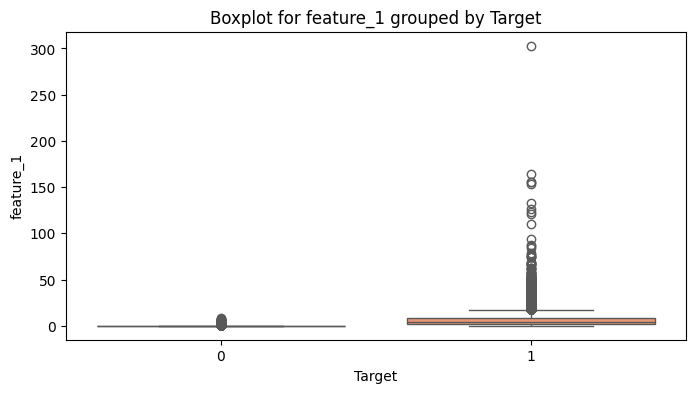

<ipython-input-26-f7f26511793f>:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='target', y=feature, palette='Set2')


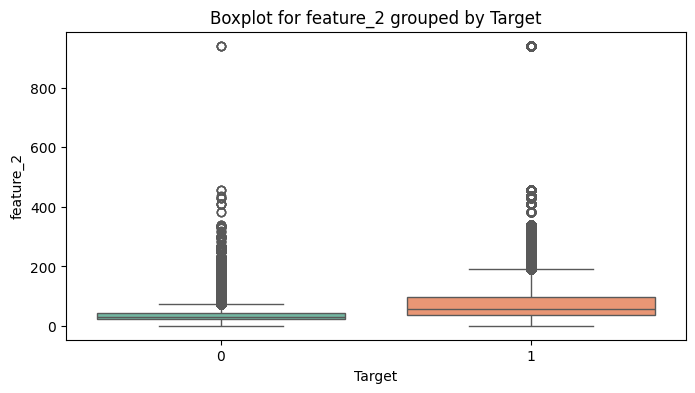

<ipython-input-26-f7f26511793f>:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='target', y=feature, palette='Set2')


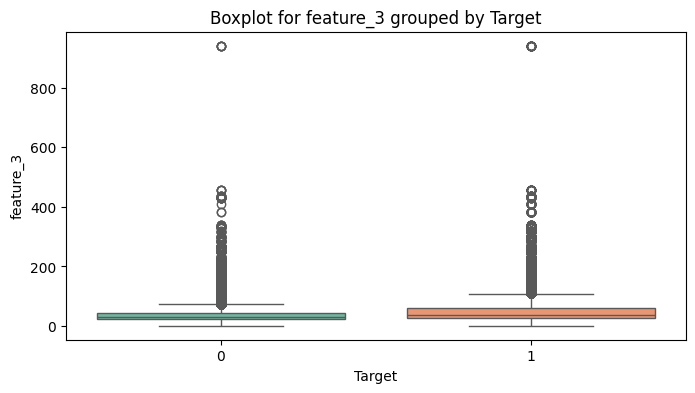

In [ ]:
# Проверка на несбалансированность

import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Построение боксплотов
for feature in df.columns[:-1]:  # Исключаем 'target'
    plt.figure(figsize=(8, 4))
    sns.boxplot(data=df, x='target', y=feature, palette='Set2')
    plt.title(f'Boxplot for {feature} grouped by Target')
    plt.xlabel('Target')
    plt.ylabel(feature)
    plt.show()

Распределение классов:
target
1    66069
0    66069
Name: count, dtype: int64


<ipython-input-27-9401e73e6aa7>:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='target', palette='Set2')


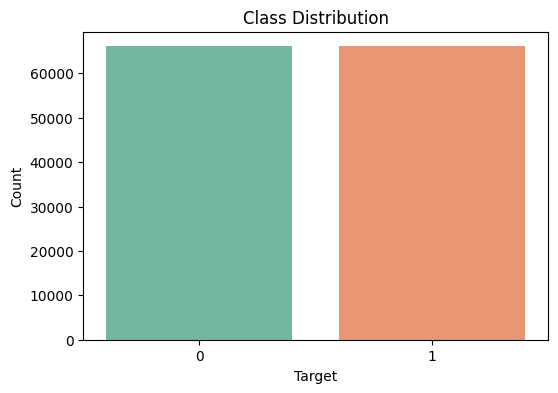

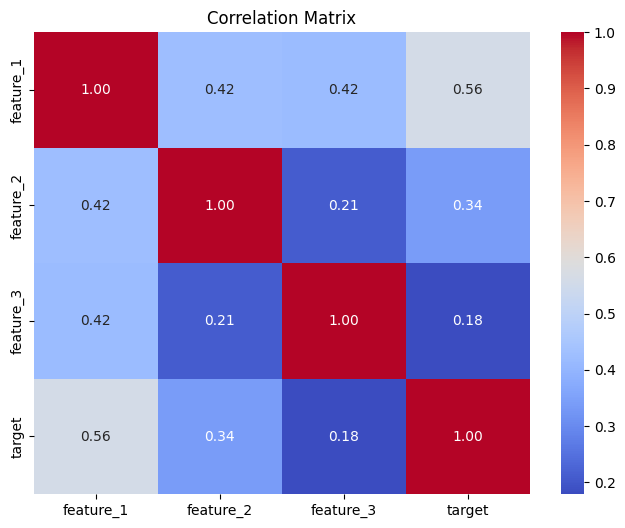

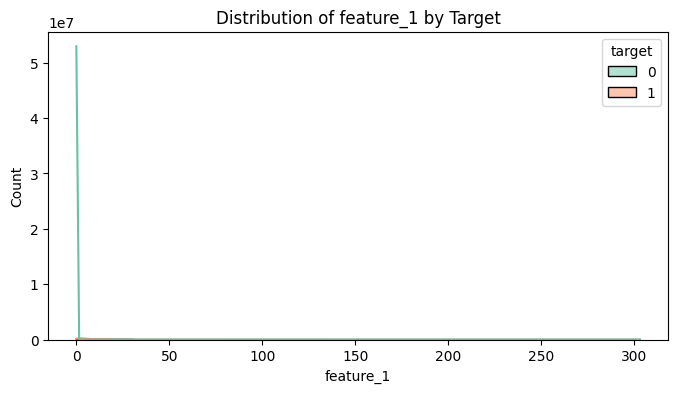

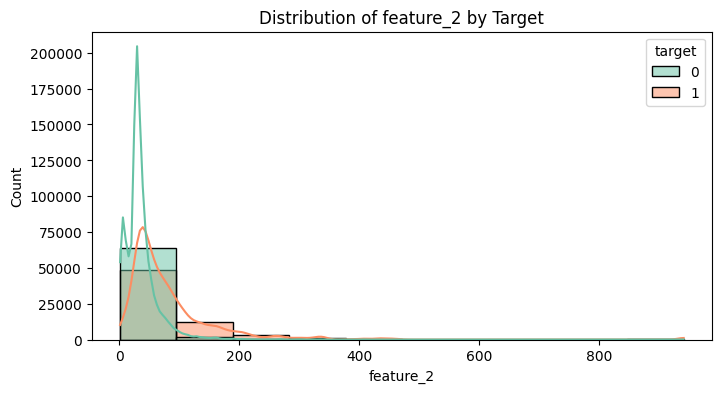

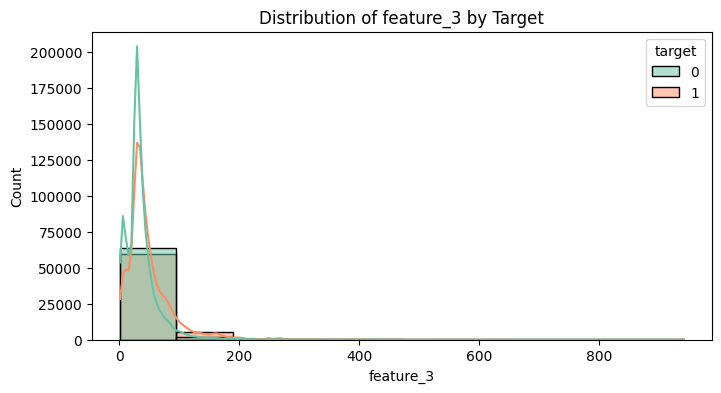

In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# 1. Распределение классов в таргете
print("Распределение классов:")
print(df['target'].value_counts())

# Построение гистограммы распределения таргета
plt.figure(figsize=(6, 4))
sns.countplot(data=df, x='target', palette='Set2')
plt.title('Class Distribution')
plt.xlabel('Target')
plt.ylabel('Count')
plt.show()

# 2. Матрица корреляций
correlation_matrix = df.corr()

# Визуализация корреляционной матрицы
plt.figure(figsize=(8, 6))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Correlation Matrix')
plt.show()

# 3. Распределение значений признаков по таргету
for feature in df.columns[:-1]:  # Исключаем 'target'
    plt.figure(figsize=(8, 4))
    sns.histplot(data=df, x=feature, hue='target', kde=True, palette='Set2', bins=10)
    plt.title(f'Distribution of {feature} by Target')
    plt.xlabel(feature)
    plt.ylabel('Count')
    plt.show()


In [ ]:
df.corr()

,feature_1,feature_2,feature_3,target
feature_1,1.000000,0.424772,0.417840,0.558199
feature_2,0.424772,1.000000,0.209505,0.338903
feature_3,0.417840,0.209505,1.000000,0.179061
target,0.558199,0.338903,0.179061,1.000000


Нейронка

In [ ]:
!pip install torch_geometric
!pip install torch

In [ ]:
import json
import networkx as nx
import torch
from torch_geometric.data import Data
from torch_geometric.nn import GATConv
import torch.nn.functional as F
import random
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics import roc_auc_score, f1_score

# === Загрузка данных и построение графа ===
file_name = "/content/drive/MyDrive/NIR_kurs2/extracted_publications_info_filtered.ndjson"
pairs_file = "/content/drive/MyDrive/NIR_kurs2/pairs_authors.json"

# Загрузка списка авторов из pairs_authors.json
with open(pairs_file, "r") as f:
    important_authors = set(json.load(f))

G = nx.Graph()
with open(file_name, "r") as file:
    for line in file:
        entry = json.loads(line)
        article_id = entry["article_id"]
        authors = [author[0] for author in entry["authors"]]
        G.add_node(article_id, year=entry["publication_year"], title=entry["title"])
        for author in authors:
            G.add_edge(article_id, author)
            if author not in G.nodes:
                G.add_node(author)

# Конвертация узлов в индексы
node_mapping = {node: i for i, node in enumerate(G.nodes)}
edges = torch.tensor([[node_mapping[u], node_mapping[v]] for u, v in G.edges]).t()

# === Фичи узлов ===
# Базовые фичи: случайные эмбеддинги
node_features = torch.rand((len(G.nodes), 16))

# Фича 1: Степень узлов
degree = torch.tensor([G.degree(node) for node in G.nodes])
node_features = torch.cat([node_features, degree.unsqueeze(1).float()], dim=1)

# Фича 2: Год публикации (для статей, 0 для остальных узлов)
years_encoded = torch.tensor([G.nodes[node].get("year", 0) for node in G.nodes])
node_features = torch.cat([node_features, years_encoded.unsqueeze(1).float()], dim=1)

# Фича 3: Количество публикаций для авторов
publication_counts = torch.tensor([
    sum(1 for neighbor in G.neighbors(node) if G.nodes[neighbor].get("year")) for node in G.nodes
])
node_features = torch.cat([node_features, publication_counts.unsqueeze(1).float()], dim=1)

# Фича 4: Количество соавторов
coauthor_counts = torch.tensor([
    len([neighbor for neighbor in G.neighbors(node) if neighbor in G.nodes]) for node in G.nodes
])
node_features = torch.cat([node_features, coauthor_counts.unsqueeze(1).float()], dim=1)

# Фича 5: TF-IDF по заголовкам
titles = [G.nodes[node].get("title", "Unknown Title") for node in G.nodes]
tfidf = TfidfVectorizer(max_features=20)
title_vectors = tfidf.fit_transform(titles).toarray()
title_tensor = torch.tensor(title_vectors).float()
node_features = torch.cat([node_features, title_tensor], dim=1)

# Фича 6: Автор важен (1 для важных авторов, 0 для остальных)
important_author_feature = torch.tensor([
    1 if node in important_authors else 0 for node in G.nodes
]).unsqueeze(1).float()
node_features = torch.cat([node_features, important_author_feature], dim=1)

# === Подготовка данных для PyTorch Geometric ===
data = Data(x=node_features, edge_index=edges)

# === Определение модели ===
class ImprovedGNN(torch.nn.Module):
    def __init__(self, input_dim, hidden_dim, output_dim, dropout=0.3):
        super(ImprovedGNN, self).__init__()
        self.conv1 = GATConv(input_dim, hidden_dim, heads=4, concat=True)
        self.conv2 = GATConv(hidden_dim * 4, output_dim, heads=1, concat=False)
        self.dropout = dropout

    def forward(self, data):
        x, edge_index = data.x, data.edge_index
        x = F.relu(self.conv1(x, edge_index))
        x = F.dropout(x, p=self.dropout, training=self.training)
        x = self.conv2(x, edge_index)
        return x

# Вычисление потерь с регуляризацией
def compute_loss_with_reg(positive_examples, negative_examples, z, model, l2_lambda=1e-4):
    pos_scores = torch.cosine_similarity(z[positive_examples[:, 0]], z[positive_examples[:, 1]])
    neg_scores = torch.cosine_similarity(z[negative_examples[:, 0]], z[negative_examples[:, 1]])

    labels = torch.cat([torch.ones_like(pos_scores), torch.zeros_like(neg_scores)])
    predictions = torch.cat([pos_scores, neg_scores])

    # Кросс-энтропийная потеря
    loss = F.binary_cross_entropy_with_logits(predictions, labels)

    # L2 регуляризация
    l2_reg = sum(torch.norm(param)**2 for param in model.parameters())
    loss += l2_lambda * l2_reg

    return loss, labels, predictions

# Создание отрицательных примеров
def get_negative_edges(G, num_samples):
    nodes = list(G.nodes)
    negative_edges = []
    for _ in range(num_samples):
        u, v = random.sample(nodes, 2)
        if not G.has_edge(u, v):
            negative_edges.append((u, v))
    return negative_edges

# === Обучение модели ===
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = ImprovedGNN(input_dim=data.x.shape[1], hidden_dim=64, output_dim=16).to(device)
data = data.to(device)

# Оптимизатор
optimizer = torch.optim.Adam(model.parameters(), lr=0.01)

model.train()
for epoch in range(50):
    optimizer.zero_grad()
    z = model(data)  # Получаем эмбеддинги узлов

    # Формируем положительные и отрицательные примеры
    positive_examples = edges.t()
    negative_examples = torch.tensor([
        [node_mapping[u], node_mapping[v]]
        for u, v in get_negative_edges(G, len(G.edges))
    ]).to(device)

    loss, labels, predictions = compute_loss_with_reg(positive_examples, negative_examples, z, model)
    loss.backward()
    optimizer.step()

    # Метрики
    roc_auc = roc_auc_score(labels.cpu().detach().numpy(), predictions.sigmoid().cpu().detach().numpy())
    f1 = f1_score(labels.cpu().detach().numpy(), (predictions.sigmoid() > 0.5).cpu().detach().numpy())

    if epoch % 10 == 0:
        print(f"Эпоха {epoch}, Потери: {loss.item():.4f}, ROC-AUC: {roc_auc:.4f}, F1-Score: {f1:.4f}")

print(f"Финальные потери: {loss.item():.4f}")


Эпоха 0, Потери: 0.7691, ROC-AUC: 0.5813, F1-Score: 0.6667
Эпоха 10, Потери: 0.6512, ROC-AUC: 0.6734, F1-Score: 0.6419
Эпоха 20, Потери: 0.6441, ROC-AUC: 0.6724, F1-Score: 0.6278
Эпоха 30, Потери: 0.6382, ROC-AUC: 0.6884, F1-Score: 0.6361
Эпоха 40, Потери: 0.6528, ROC-AUC: 0.6937, F1-Score: 0.6437
Финальные потери: 0.6361


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
# === Проверка на случайных сэмплах ===
import random

def evaluate_samples(G, z, node_mapping, num_samples=5):
    # Случайные положительные примеры
    positive_samples = random.sample(list(G.edges), num_samples)
    positive_indices = torch.tensor([
        [node_mapping[u], node_mapping[v]] for u, v in positive_samples
    ])
    pos_scores = torch.cosine_similarity(
        z[positive_indices[:, 0]], z[positive_indices[:, 1]]
    ).sigmoid()

    # Случайные отрицательные примеры
    negative_samples = get_negative_edges(G, num_samples)
    negative_indices = torch.tensor([
        [node_mapping[u], node_mapping[v]] for u, v in negative_samples
    ])
    neg_scores = torch.cosine_similarity(
        z[negative_indices[:, 0]], z[negative_indices[:, 1]]
    ).sigmoid()

    # Вывод результатов
    print("\n=== Проверка на случайных сэмплах ===")
    print("Положительные примеры (должны быть высокие оценки):")
    for (u, v), score in zip(positive_samples, pos_scores.tolist()):
        print(f"Узлы: ({u}, {v}), Оценка: {score:.4f}")

    print("\nОтрицательные примеры (должны быть низкие оценки):")
    for (u, v), score in zip(negative_samples, neg_scores.tolist()):
        print(f"Узлы: ({u}, {v}), Оценка: {score:.4f}")

# После завершения обучения
model.eval()
with torch.no_grad():
    z = model(data)  # Финальные эмбеддинги узлов
    evaluate_samples(G, z, node_mapping)


NameError: name 'model' is not defined

###Основная модель сверху

New Version

Sergey Kovalchuk, [03.02.2025 14:52]
ну, смотри, я думаю, надо сделать так.
1. строим граф за каждый год по этому и предыдущим годам.
2. строим граф по всем годам.
3. по графу из п.1 пытаемся предсказать появление ребер в графе из п.2 (там где таких ребер еще нет).
4. пробуем повторить эксперимент, но вместо общего графа из п.2 берем граф за +N лет от текущего. Оцениваем качество в зависимости от N

Начын Доржу, [03.02.2025 15:05]
А в графе в п.1 если автор еще не публиковался, то оставить его узел или убрать? И то есть для первого пункта надо будет иметь 24 разных графов для каждого года? И на счет фичи с парами авторов, их оставить? Потому что мне кажется, что в данном случае они влияния не имеют

Sergey Kovalchuk, [03.02.2025 15:07]
да, для каждого года будет свой граф

Sergey Kovalchuk, [03.02.2025 15:08]
Вершины, которые не публиковались, можно оставить без связей. А можно вообще удалить из рассмотрения. Можно сделать два эксперимента

Sergey Kovalchuk, [03.02.2025 15:08]
Про фичу - поясни, что имеешь ввиду

Начын Доржу, [03.02.2025 15:13]
Я эту фичу сделал так. Если автор был в списке этих авторов, то у него значение 1, если нет то 0. То есть у меня эта фича имеет смысл как паттерн поведения, подверженны ли они новым коллаборациям. И мне показалось, что данная фича не будет иметь веса в данном контексте

Sergey Kovalchuk, [03.02.2025 15:15]
кажется она и так через топологию графа видна, так что думаю, можно и без нее

Начын Доржу, [03.02.2025 15:37]
Понял

Sergey Kovalchuk, [03.02.2025 16:05]
Да, предсказываем линк только для тех, кто в этот год представлен на конференции

Sergey Kovalchuk, [03.02.2025 16:06]
Можно кстати, сделать ради интереса такой сервис - выдавать список, с кем может возникнуть линк. "Приложение для знакомств на конференции" :)))

Начын Доржу, [03.02.2025 16:13]
Вводить имя автора и получать список возможных авторов?

Sergey Kovalchuk, [03.02.2025 16:14]
ну, по идее можно это рассчитать для всех кто будет на конференции. И для каждого выдать, например, топ-10 потенциальных контактов

Начын Доржу, [03.02.2025 16:15]
Понял, хорошо

In [ ]:
# п.2 строим граф по всем годам
import json
import networkx as nx

file_name = "/content/drive/MyDrive/NIR_kurs2/extracted_publications_info_filtered.ndjson"

with open(file_name, "r") as f:
  publications = [json.loads(line) for line in f]

G_all = nx.MultiGraph()
for pub in publications:
  authors = [a[0] for a in pub["authors"]]
  for i in range(len(authors)):
    for j in range(i + 1, len(authors)):
      G_all.add_edge(authors[i], authors[j], article_id=pub["article_id"], year=pub["publication_year"])

In [ ]:
works_id = '/content/drive/MyDrive/NIR_kurs2/works_id.txt'

with open(works_id, "r") as f:
  iccs_works = [line.strip() for line in f]

edges = list(G_all.edges(keys=True, data=True))

for el in edges:
  if el[3]['article_id'] in iccs_works:
    G_all[el[0]][el[1]][el[2]]['iccs'] = True
  else:
    G_all[el[0]][el[1]][el[2]]['iccs'] = False

In [ ]:
import networkx as nx
# Сохраняем граф
# nx.write_graphml(G_all, "graph_all_years.graphml")
G_all = nx.read_graphml("graph_all_years.graphml")

In [ ]:
print(G_all.number_of_edges())
print(G_all.number_of_nodes())

601627
15724


2001-2023

In [ ]:
G_all.degree('A5084949021')

319

In [ ]:
for el in graphs_by_year:
  print(el, graphs_by_year[el].number_of_edges())

2001 14331
2002 21730
2003 33610
2004 51394
2005 71262
2006 94484
2007 116899
2008 148997
2009 171827
2010 193669
2011 229791
2012 255131
2013 291332
2014 320678
2015 347475
2016 377963
2017 401014
2018 427537
2019 457212
2020 496063
2021 529192
2022 554708
2023 589420


In [ ]:
# п.1
# удаляем с последнего года до 2001 года, сохраняем графы

graphs_by_year = {}  # Словарь для хранения графов по годам

for i in range(2001, 2024):  # 2001 - 2023
    G_year = G_all.copy()  # Делаем копию графа на текущий год

    edges = list(G_year.edges(keys=True, data=True))
    for el in edges:
        if el[3]['year'] > i:  # Удаляем рёбра, которые ещё не появились в этом году
            G_year.remove_edge(el[0], el[1], el[2])

    graphs_by_year[i] = G_year  # Сохраняем копию графа в словарь

In [ ]:
# Удалим из каждых графов узлы у которых нет ребер
# Пока что оставим, для следующего раза

In [ ]:
import networkx as nx
import random

positive_examples_by_year = {}
negative_examples_by_year = {}

for year in range(2001, 2023):  # Смотрим с 2001 по 2022 (чтобы был следующий год)
  positive_examples = []
  negative_examples = []
  G_current = graphs_by_year[year]   # Граф на текущий год
  G_next = graphs_by_year[year + 1]  # Граф на следующий год

  # Берём только рёбра, которые появились **именно в этом году**:
  edges_this_year = [(u, v) for u, v, k, d in G_current.edges(keys=True, data=True) if d['year'] == year and d['iccs']  == True]

  # Проверяем, появились ли эти рёбра в следующем году (положительные примеры)
  for u, v in edges_this_year:
    if not G_current.has_edge(u, v) and G_next.has_edge(u, v):  # Ребро появилось
      positive_examples.append((u, v, year + 1))  # (автор1, автор2, год появления)

  # shaffle edges_this_year
  random.shuffle(edges_this_year)
  # Выбираем случайные пары из возможных, но не существующих рёбер (отрицательные примеры)
  while len(negative_examples) < len(positive_examples):
    for u, v in edges_this_year:
      if not G_current.has_edge(u, v) and not G_next.has_edge(u, v):  # Проверяем, что связь не появилась в будущем
        negative_examples.append((u, v, year + 1))  # (автор1, автор2, год, когда могло появиться)

  positive_examples_by_year[year] = positive_examples
  negative_examples_by_year[year] = negative_examples


In [ ]:
for el in negative_examples_by_year:
  print(len(positive_examples_by_year[el]))

0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0


In [ ]:
import json
import networkx as nx
import random
import torch
import torch.nn.functional as F
from copy import deepcopy
from torch_geometric.data import Data
from torch_geometric.utils import from_networkx
from torch_geometric.nn import GATConv
from sklearn.metrics import roc_auc_score

##########################################
# Step 1: Build Temporal Graphs by Year
##########################################
G_all = nx.read_graphml("graph_all_years.graphml")
# Создаём словарь графов по годам: для каждого года (2001-2023) оставляем только рёбра, появившиеся до и в этом году
graphs_by_year = {}
G_full = G_all.copy()
for year in range(2001, 2024):  # 2001-2023
    G_year = G_full.copy()
    edges = list(G_year.edges(keys=True, data=True))
    for el in edges:
        if int(el[3]['year']) > year:  # Удаляем рёбра, которые появились позже данного года
            G_year.remove_edge(el[0], el[1], el[2])
    graphs_by_year[year] = G_year

##########################################
# Step 2: Form Positive and Negative Examples
##########################################
# Для каждого года (2001-2022) рассматриваем рёбра, появившиеся именно в этом году.
# Если в следующем году между той же парой узлов появляется ребро, то добавляем как положительный пример.
# Иначе - как отрицательный пример.

positive_examples = []
negative_examples = []

for year in range(2001, 2023):  # для годов 2001-2022 (так как для 2023 нет "следующего" года)
    G_current = graphs_by_year[year]
    G_next = graphs_by_year[year + 1]

    # Рёбра, появившиеся именно в этом году
    edges_this_year = [(u, v) for u, v, k, d in G_current.edges(keys=True, data=True) if int(d['year']) == year]

    # Для каждого ребра из этого списка проверяем, появилось ли оно в графе следующего года.
    for u, v in edges_this_year:
        # Если ребро (между той же парой узлов) присутствует в графе следующего года – положительный пример.
        if G_next.has_edge(u, v):
            positive_examples.append((u, v, year + 1))
        else:
            negative_examples.append((u, v, year + 1))

    # Можно дополнительно добавить отрицательные примеры из несуществующих ребер, но здесь используем только пары,
    # которые уже имели появление в текущем году как условие.

##########################################
# Step 3: Prepare Dataset for Link Prediction
##########################################
# Объединяем положительные и отрицательные примеры с метками (1 - положительный, 0 - отрицательный)
data_examples = []
for ex in positive_examples:
    data_examples.append((ex[0], ex[1], ex[2], 1))
for ex in negative_examples:
    data_examples.append((ex[0], ex[1], ex[2], 0))

random.shuffle(data_examples)

# Для формирования фичей используем упрощённый вариант полного графа (без мультиграфа)
G_simple = nx.Graph(G_all)
data_pg = from_networkx(G_simple)
num_nodes = data_pg.num_nodes

# Создаём one-hot представление узлов (можно заменить на другие признаки)
data_pg.x = torch.eye(num_nodes)

# Словарь для сопоставления идентификаторов авторов с индексами узлов
node_to_idx = {node: i for i, node in enumerate(G_simple.nodes())}

# Формируем списки для обучения
src_list, dst_list, labels_list = [], [], []
for (u, v, year, label) in data_examples:
    if u in node_to_idx and v in node_to_idx:
        src_list.append(node_to_idx[u])
        dst_list.append(node_to_idx[v])
        labels_list.append(label)

src_tensor = torch.tensor(src_list, dtype=torch.long)
dst_tensor = torch.tensor(dst_list, dtype=torch.long)
labels_tensor = torch.tensor(labels_list, dtype=torch.float)

##########################################
# Step 4: Define the GAT Model for Link Prediction
##########################################
class GATModel(torch.nn.Module):
    def __init__(self, in_channels, hidden_channels, out_channels, heads=3, dropout=0.3, weight_decay=5e-4):
        super(GATModel, self).__init__()
        self.weight_decay = weight_decay
        self.dropout = dropout
        # Первый слой GAT с многоголовым вниманием
        self.conv1 = GATConv(in_channels, hidden_channels, heads=heads, dropout=dropout)
        # Второй слой GAT для получения финальных эмбеддингов
        self.conv2 = GATConv(hidden_channels * heads, out_channels, heads=1, concat=False, dropout=dropout)
        # Полносвязный слой для объединения эмбеддингов пары узлов и предсказания вероятности связи
        self.fc = torch.nn.Linear(out_channels * 2, 1)

    def forward(self, x, edge_index, src, dst):
        x = self.conv1(x, edge_index)
        x = F.elu(x)
        x = F.dropout(x, p=self.dropout, training=self.training)
        x = self.conv2(x, edge_index)

        h_src = x[src]
        h_dst = x[dst]
        h = torch.cat([h_src, h_dst], dim=1)
        out = self.fc(h)
        return out.squeeze()

    def l2_regularization(self):
        reg_loss = 0
        for param in self.parameters():
            reg_loss += torch.norm(param, p=2)
        return self.weight_decay * reg_loss

##########################################
# Step 5: Training and Evaluation
##########################################
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model = GATModel(in_channels=num_nodes, hidden_channels=64, out_channels=64, dropout=0.3).to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=0.005, weight_decay=5e-4)
criterion = torch.nn.BCEWithLogitsLoss()

data_pg = data_pg.to(device)
src_tensor = src_tensor.to(device)
dst_tensor = dst_tensor.to(device)
labels_tensor = labels_tensor.to(device)

model.train()
num_epochs = 50
for epoch in range(1, num_epochs + 1):
    optimizer.zero_grad()
    logits = model(data_pg.x, data_pg.edge_index, src_tensor, dst_tensor)
    loss = criterion(logits, labels_tensor) + model.l2_regularization()
    loss.backward()
    optimizer.step()

    if epoch % 10 == 0:
        with torch.no_grad():
            preds = torch.sigmoid(logits)
            predicted = (preds > 0.5).float()
            accuracy = (predicted == labels_tensor).float().mean().item()
            auc = roc_auc_score(labels_tensor.cpu().numpy(), preds.cpu().numpy())
        print(f"Epoch {epoch:03d}, Loss: {loss.item():.4f}, Accuracy: {accuracy:.4f}, AUC: {auc:.4f}")

model.eval()
with torch.no_grad():
    logits = model(data_pg.x, data_pg.edge_index, src_tensor, dst_tensor)
    preds = torch.sigmoid(logits)
    predicted = (preds > 0.5).float()
    accuracy = (predicted == labels_tensor).float().mean().item()
    auc = roc_auc_score(labels_tensor.cpu().numpy(), preds.cpu().numpy())
    print("Final Accuracy:", accuracy)
    print("Final ROC-AUC:", auc)


/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_ranking.py:379: UndefinedMetricWarning: Only one class is present in y_true. ROC AUC score is not defined in that case.
  warnings.warn(


Epoch 010, Loss: 0.0393, Accuracy: 1.0000, AUC: nan


/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_ranking.py:379: UndefinedMetricWarning: Only one class is present in y_true. ROC AUC score is not defined in that case.
  warnings.warn(


Epoch 020, Loss: 0.0127, Accuracy: 1.0000, AUC: nan


/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_ranking.py:379: UndefinedMetricWarning: Only one class is present in y_true. ROC AUC score is not defined in that case.
  warnings.warn(


...

/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_ranking.py:379: UndefinedMetricWarning: Only one class is present in y_true. ROC AUC score is not defined in that case.
  warnings.warn(


Epoch 040, Loss: 0.0087, Accuracy: 1.0000, AUC: nan


/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_ranking.py:379: UndefinedMetricWarning: Only one class is present in y_true. ROC AUC score is not defined in that case.
  warnings.warn(


Epoch 050, Loss: 0.0072, Accuracy: 1.0000, AUC: nan
Final Accuracy: 1.0
Final ROC-AUC: nan


/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_ranking.py:379: UndefinedMetricWarning: Only one class is present in y_true. ROC AUC score is not defined in that case.
  warnings.warn(


In [ ]:
import numpy as np

def precision_at_k(y_true, y_scores, k):
    sorted_indices = np.argsort(y_scores)[::-1][:k]
    top_k_labels = np.array(y_true)[sorted_indices]
    return np.sum(top_k_labels) / k

precision_k = precision_at_k(y_true, y_pred, k=50)


In [ ]:
def construct_temporal_graph(G_all, target_year, N):
    G_N = nx.MultiGraph()
    for u, v, key, data in G_all.edges(keys=True, data=True):
        if data['year'] >= target_year - N and data['year'] < target_year:
            G_N.add_edge(u, v, key=key, year=data['year'])
    return G_N


In [ ]:
!pip install torch_geometric

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 63.1/63.1 kB 4.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.1/1.1 MB 56.7 MB/s eta 0:00:00


In [ ]:
import json
import networkx as nx
import torch
from torch_geometric.data import Data
from torch_geometric.nn import GATConv
import torch.nn.functional as F
import random
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics import roc_auc_score, f1_score
import matplotlib.pyplot as plt
from sklearn.manifold import TSNE

# === Загрузка данных и построение графа ===
file_name = "/content/drive/MyDrive/NIR_kurs2/extracted_publications_info_filtered.ndjson"

G = nx.Graph()
with open(file_name, "r") as file:
    for line in file:
        entry = json.loads(line)
        article_id = entry["article_id"]
        authors = [author[0] for author in entry["authors"]]
        G.add_node(article_id, year=entry["publication_year"], title=entry["title"])
        for author in authors:
            G.add_edge(article_id, author)
            if author not in G.nodes:
                G.add_node(author)

# Конвертация узлов в индексы
node_mapping = {node: i for i, node in enumerate(G.nodes)}
edges = torch.tensor([[node_mapping[u], node_mapping[v]] for u, v in G.edges]).t()

# === Формирование фич узлов ===
# Базовые фичи: случайные эмбеддинги
node_features = torch.rand((len(G.nodes), 16))

# Фича 1: Степень узлов
degree = torch.tensor([G.degree(node) for node in G.nodes])
node_features = torch.cat([node_features, degree.unsqueeze(1).float()], dim=1)

# Фича 2: Год публикации (для статей, 0 для остальных узлов)
years_encoded = torch.tensor([G.nodes[node].get("year", 0) for node in G.nodes])
node_features = torch.cat([node_features, years_encoded.unsqueeze(1).float()], dim=1)

# Фича 3: Количество публикаций для авторов
publication_counts = torch.tensor([
    sum(1 for neighbor in G.neighbors(node) if G.nodes[neighbor].get("year")) for node in G.nodes
])
node_features = torch.cat([node_features, publication_counts.unsqueeze(1).float()], dim=1)

# Фича 4: Количество соавторов
coauthor_counts = torch.tensor([
    len([neighbor for neighbor in G.neighbors(node) if neighbor in G.nodes]) for node in G.nodes
])
node_features = torch.cat([node_features, coauthor_counts.unsqueeze(1).float()], dim=1)

# Фича 5: TF-IDF по заголовкам
titles = [G.nodes[node].get("title", "Unknown Title") for node in G.nodes]
tfidf = TfidfVectorizer(max_features=20)
title_vectors = tfidf.fit_transform(titles).toarray()
title_tensor = torch.tensor(title_vectors).float()
node_features = torch.cat([node_features, title_tensor], dim=1)

# === Подготовка данных для PyTorch Geometric ===
data = Data(x=node_features, edge_index=edges)

# === Определение модели ===
class ImprovedGNN(torch.nn.Module):
    def __init__(self, input_dim, hidden_dim, output_dim, dropout=0.3):
        super(ImprovedGNN, self).__init__()
        self.conv1 = GATConv(input_dim, hidden_dim, heads=4, concat=True)
        self.conv2 = GATConv(hidden_dim * 4, output_dim, heads=1, concat=False)
        self.dropout = dropout

    def forward(self, data):
        x, edge_index = data.x, data.edge_index
        x = F.relu(self.conv1(x, edge_index))
        x = F.dropout(x, p=self.dropout, training=self.training)
        x = self.conv2(x, edge_index)
        return x

# Функция вычисления потерь с регуляризацией
def compute_loss_with_reg(positive_examples, negative_examples, z, model, l2_lambda=1e-4):
    pos_scores = torch.cosine_similarity(z[positive_examples[:, 0]], z[positive_examples[:, 1]])
    neg_scores = torch.cosine_similarity(z[negative_examples[:, 0]], z[negative_examples[:, 1]])

    labels = torch.cat([torch.ones_like(pos_scores), torch.zeros_like(neg_scores)])
    predictions = torch.cat([pos_scores, neg_scores])

    loss = F.binary_cross_entropy_with_logits(predictions, labels)
    l2_reg = sum(torch.norm(param)**2 for param in model.parameters())
    loss += l2_lambda * l2_reg
    return loss, labels, predictions

# Функция создания отрицательных примеров
def get_negative_edges(G, num_samples):
    nodes = list(G.nodes)
    negative_edges = []
    while len(negative_edges) < num_samples:
        u, v = random.sample(nodes, 2)
        if not G.has_edge(u, v):
            negative_edges.append((u, v))
    return negative_edges

# === Обучение модели ===
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = ImprovedGNN(input_dim=data.x.shape[1], hidden_dim=64, output_dim=16).to(device)
data = data.to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=0.01)

# Списки для сохранения метрик по эпохам
losses = []
roc_aucs = []
f1s = []
epochs_list = []

model.train()
for epoch in range(50):
    optimizer.zero_grad()
    z = model(data)  # Получаем эмбеддинги узлов

    # Формирование положительных и отрицательных примеров
    positive_examples = edges.t()
    negative_edges = get_negative_edges(G, len(G.edges))
    negative_examples = torch.tensor([
        [node_mapping[u], node_mapping[v]] for u, v in negative_edges
    ]).to(device)

    loss, labels, predictions = compute_loss_with_reg(positive_examples, negative_examples, z, model)
    loss.backward()
    optimizer.step()

    # Вычисление метрик
    roc_auc = roc_auc_score(labels.cpu().detach().numpy(), predictions.sigmoid().cpu().detach().numpy())
    f1 = f1_score(labels.cpu().detach().numpy(), (predictions.sigmoid() > 0.5).cpu().detach().numpy())

    losses.append(loss.item())
    roc_aucs.append(roc_auc)
    f1s.append(f1)
    epochs_list.append(epoch)

    if epoch % 10 == 0:
        print(f"Эпоха {epoch}, Потери: {loss.item():.4f}, ROC-AUC: {roc_auc:.4f}, F1-Score: {f1:.4f}")

print(f"Финальные потери: {loss.item():.4f}")

# === Построение графиков ===

# 1. Графики изменения метрик по эпохам: Потери, ROC-AUC и F1-Score
plt.figure(figsize=(18, 5))

plt.subplot(1, 3, 1)
plt.plot(epochs_list, losses, marker='o', color='blue')
plt.title("Значение функции потерь")
plt.xlabel("Эпоха")
plt.ylabel("Потери")

plt.subplot(1, 3, 2)
plt.plot(epochs_list, roc_aucs, marker='o', color='green')
plt.title("ROC-AUC по эпохам")
plt.xlabel("Эпоха")
plt.ylabel("ROC-AUC")

plt.subplot(1, 3, 3)
plt.plot(epochs_list, f1s, marker='o', color='red')
plt.title("F1-Score по эпохам")
plt.xlabel("Эпоха")
plt.ylabel("F1-Score")

plt.tight_layout()
plt.show()

ICCS 2025

In [ ]:
import json
import networkx as nx

# Первый проход: соберём авторов, у которых есть статьи с id == 'not published'
valid_authors = set()

with open('dataset.ndjson', 'r', encoding='utf-8') as f:
    for line in f:
        record = json.loads(line)
        if record.get('id') == 'not published':
            authors = eval(record['authors'])  # строка → список
            valid_authors.update(authors)

# Cтроим граф с фильтрацией авторов
G = nx.MultiGraph()

with open('dataset.ndjson', 'r', encoding='utf-8') as f:
    for line in f:
        record = json.loads(line)
        authors = eval(record['authors'])
        title = record['title']
        pub_year = record.get('publication_year')
        paper_id = record.get('id')
        index = record.get('index')

        # Добавляем в граф только тех авторов, которые допустимы
        filtered_authors = [a for a in authors if a in valid_authors]

        # Добавляем узлы
        for author in filtered_authors:
            if not G.has_node(author):
                G.add_node(author)

        # Добавляем рёбра между всеми допустимыми соавторами
        for i in range(len(filtered_authors)):
            for j in range(i + 1, len(filtered_authors)):
                G.add_edge(
                    filtered_authors[i],
                    filtered_authors[j],
                    title=title,
                    publication_year=pub_year,
                    id=paper_id,
                    index=index
                )

In [ ]:
print("Всего авторов:", G.number_of_nodes())
print("Всего соавторств:", G.number_of_edges())

author_a = "Remigiusz Martyniak"
author_b = "Mariusz Dzwonkowski"

if G.has_edge(author_a, author_b):
    for i, data in enumerate(G.get_edge_data(author_a, author_b).values()):
        print(f"[#{i+1}] Статья: {data['title']}, год: {data['publication_year']}")

Всего авторов: 938
Всего соавторств: 6470
[#1] Статья: Reversible Data Hiding in Encrypted Images with Pixel Prediction and ERLE Compression, год: 2025


Модель

In [ ]:
!pip install torch_geometric

Эпоха 0, Потери: 0.7491, ROC-AUC: 0.8509, F1: 0.6667
Эпоха 10, Потери: 0.5830, ROC-AUC: 0.8832, F1: 0.7711
Эпоха 20, Потери: 0.5703, ROC-AUC: 0.9002, F1: 0.7804
Эпоха 30, Потери: 0.5611, ROC-AUC: 0.9176, F1: 0.7871
Эпоха 40, Потери: 0.5585, ROC-AUC: 0.9200, F1: 0.7937
Финальные потери: 0.5548


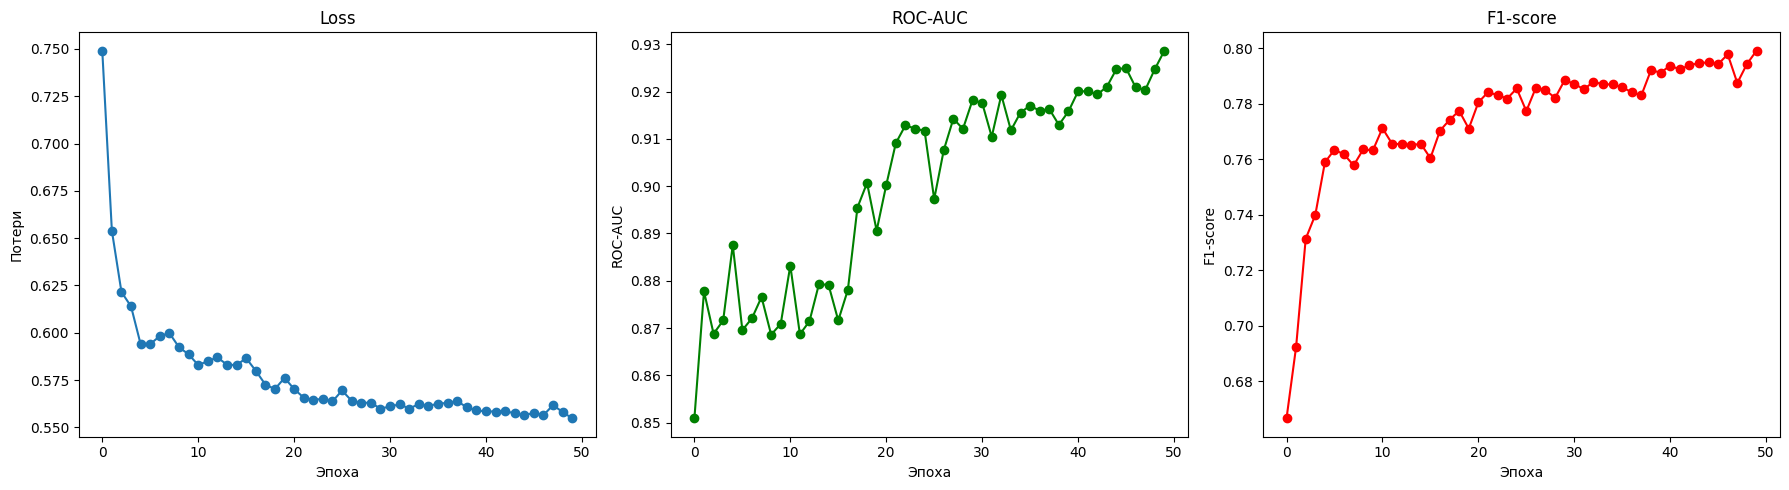

In [ ]:
import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt
import networkx as nx
import random
from torch_geometric.data import Data
from torch_geometric.nn import GATConv
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics import roc_auc_score, f1_score

# === Конвертация узлов в индексы ===
node_mapping = {node: i for i, node in enumerate(G.nodes)}
edges = torch.tensor([[node_mapping[u], node_mapping[v]] for u, v in G.edges()], dtype=torch.long).t()

# === Фичи узлов ===
# Случайные эмбеддинги
node_features = torch.rand((len(G.nodes), 16))

# Фича 1: Степень узлов
degree = torch.tensor([G.degree(node) for node in G.nodes])
node_features = torch.cat([node_features, degree.unsqueeze(1).float()], dim=1)

# Фича 2: Год публикации (только для статей)
years_encoded = torch.tensor([G.nodes[node].get("year", 0) for node in G.nodes])
node_features = torch.cat([node_features, years_encoded.unsqueeze(1).float()], dim=1)

# Фича 3: Кол-во публикаций (только у авторов)
publication_counts = torch.tensor([
    sum(1 for neighbor in G.neighbors(node) if G.nodes[neighbor].get("year")) for node in G.nodes
])
node_features = torch.cat([node_features, publication_counts.unsqueeze(1).float()], dim=1)

# Фича 4: Кол-во соавторов
coauthor_counts = torch.tensor([
    len([n for n in G.neighbors(node) if isinstance(n, str)]) for node in G.nodes
])
node_features = torch.cat([node_features, coauthor_counts.unsqueeze(1).float()], dim=1)

# === Подготовка данных ===
data = Data(x=node_features, edge_index=edges)

# === Определение модели ===
class ImprovedGNN(torch.nn.Module):
    def __init__(self, input_dim, hidden_dim, output_dim, dropout=0.3):
        super(ImprovedGNN, self).__init__()
        self.conv1 = GATConv(input_dim, hidden_dim, heads=4, concat=True)
        self.conv2 = GATConv(hidden_dim * 4, output_dim, heads=1, concat=False)
        self.dropout = dropout

    def forward(self, data):
        x, edge_index = data.x, data.edge_index
        x = F.relu(self.conv1(x, edge_index))
        x = F.dropout(x, p=self.dropout, training=self.training)
        x = self.conv2(x, edge_index)
        return x

# === Вспомогательные функции ===
def compute_loss_with_reg(positive_examples, negative_examples, z, model, l2_lambda=1e-4):
    pos_scores = torch.cosine_similarity(z[positive_examples[:, 0]], z[positive_examples[:, 1]])
    neg_scores = torch.cosine_similarity(z[negative_examples[:, 0]], z[negative_examples[:, 1]])
    labels = torch.cat([torch.ones_like(pos_scores), torch.zeros_like(neg_scores)])
    predictions = torch.cat([pos_scores, neg_scores])
    loss = F.binary_cross_entropy_with_logits(predictions, labels)
    l2_reg = sum(torch.norm(param)**2 for param in model.parameters())
    return loss + l2_lambda * l2_reg, labels, predictions

def get_negative_edges(G, num_samples):
    nodes = list(G.nodes)
    edges_set = set(G.edges)
    negative_edges = []
    while len(negative_edges) < num_samples:
        u, v = random.sample(nodes, 2)
        if (u, v) not in edges_set and (v, u) not in edges_set:
            negative_edges.append((u, v))
    return negative_edges

# === Обучение ===
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = ImprovedGNN(input_dim=data.x.shape[1], hidden_dim=64, output_dim=16).to(device)
data = data.to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=0.01)

losses, roc_aucs, f1s, epochs_list = [], [], [], []

model.train()
for epoch in range(50):
    optimizer.zero_grad()
    z = model(data)

    positive_examples = edges.t()
    negative_examples = get_negative_edges(G, len(G.edges))
    negative_examples = torch.tensor([
        [node_mapping[u], node_mapping[v]] for u, v in negative_examples
    ], dtype=torch.long).to(device)

    loss, labels, predictions = compute_loss_with_reg(positive_examples, negative_examples, z, model)
    loss.backward()
    optimizer.step()

    roc_auc = roc_auc_score(labels.cpu().detach().numpy(), predictions.sigmoid().cpu().detach().numpy())
    f1 = f1_score(
    labels.cpu().detach().numpy(),
    (predictions.sigmoid() > 0.5).cpu().detach().numpy()
    )

    losses.append(loss.item())
    roc_aucs.append(roc_auc)
    f1s.append(f1)
    epochs_list.append(epoch)

    if epoch % 10 == 0:
        print(f"Эпоха {epoch}, Потери: {loss.item():.4f}, ROC-AUC: {roc_auc:.4f}, F1: {f1:.4f}")

print(f"Финальные потери: {loss.item():.4f}")

# === Графики ===
plt.figure(figsize=(18, 5))
plt.subplot(1, 3, 1)
plt.plot(epochs_list, losses, marker='o')
plt.title("Loss")
plt.xlabel("Эпоха")
plt.ylabel("Потери")

plt.subplot(1, 3, 2)
plt.plot(epochs_list, roc_aucs, marker='o', color='green')
plt.title("ROC-AUC")
plt.xlabel("Эпоха")
plt.ylabel("ROC-AUC")

plt.subplot(1, 3, 3)
plt.plot(epochs_list, f1s, marker='o', color='red')
plt.title("F1-score")
plt.xlabel("Эпоха")
plt.ylabel("F1-score")

plt.tight_layout()
plt.show()


In [ ]:
from tqdm import tqdm

# Словари соответствия: имя узла ↔ индекс тензора
node_mapping = {node: i for i, node in enumerate(G.nodes)}
inv_node_mapping = {i: node for node, i in node_mapping.items()}

# Получаем список только авторов
author_nodes = G.nodes

# Предсказание топ-10 новых связей для каждого автора
top_k_predictions = {}
z = model(data).detach().cpu()  # эмбеддинги

for author in tqdm(author_nodes):
    a_idx = node_mapping[author]

    scores = []
    for other in author_nodes:
        if other == author:
            continue
        if not G.has_edge(author, other):  # нет существующей коллаборации
            b_idx = node_mapping[other]
            score = F.cosine_similarity(z[a_idx].unsqueeze(0), z[b_idx].unsqueeze(0)).item()
            scores.append((other, score))

    # Сортируем по убыванию вероятности
    top_10 = sorted(scores, key=lambda x: x[1], reverse=True)[:10]
    top_k_predictions[author] = top_10


100%|██████████| 938/938 [00:55<00:00, 16.96it/s]


In [ ]:
import json

with open("predicted_collaborations.json", "w") as f:
    json.dump(top_k_predictions, f, indent=2)

In [ ]:
torch.save(model.state_dict(), "improved_gnn_model.pth")
torch.save(model, "improved_gnn_model_full.pth")

In [ ]:
model = ImprovedGNN(input_dim=..., hidden_dim=64, output_dim=16)
model.load_state_dict(torch.load("improved_gnn_model.pth"))
model.eval()

In [ ]:
model = torch.load("improved_gnn_model_full.pth")
model.eval()